# Sandbox for exploratory data analysis (EDA)

Import nescessary modules and load dataset to `pandas.DataFrame`

In [14]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

'''
Datasets for sandbox were downloaded from kaggle using:
curl -L -o ~/Downloads/netflix-movies-and-tv-shows-till-2025.zip\
  https://www.kaggle.com/api/v1/datasets/download/bhargavchirumamilla/netflix-movies-and-tv-shows-till-2025
'''

df = pd.read_csv('netflix_movies_detailed_up_to_2025.csv')

The number of records in each column, type of data, whether any values are missing and how much memory the dataset uses.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  str    
 2   title         16000 non-null  str    
 3   director      15868 non-null  str    
 4   cast          15796 non-null  str    
 5   country       15534 non-null  str    
 6   date_added    16000 non-null  str    
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  str    
 11  language      16000 non-null  str    
 12  description   15868 non-null  str    
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), str(9)
memor

After running the code above it's clear that *duration* column is empty and some columns, i.e. *director* or *cast*, have empty (null) values. The code below will generate a statistical summary of the `movies_df` DataFrame showing values like count, mean, standard deviation, minimum and quartiles for each numerical column.

In [ ]:
# 1. Remove empty column
#    Instruction is placed inside if statement because the operation is done in place 
if 'duration' in df.columns:
    df.drop(columns=['duration'], inplace=True)  # labels, axis=1 --> columns

# 2. Date conversion
df['date_added'] = pd.to_datetime(df['date_added'])

df.describe().T

,count,mean,min,25%,50%,75%,max,std
show_id,16000.0,526658.174813,189.0,225725.75,446817.0,773980.75,1440471.0,379442.71883
date_added,16000,2018-01-04 21:54:37.800000,2010-01-01 00:00:00,2013-12-31 18:00:00,2017-12-31 12:00:00,2021-12-31 06:00:00,2025-12-25 00:00:00,NaN
release_year,16000.0,2017.5,2010.0,2013.75,2017.5,2021.25,2025.0,4.609916
rating,16000.0,5.956368,0.0,5.6,6.3,6.923,10.0,1.754741
popularity,16000.0,20.384728,3.86,7.84075,10.9135,17.3365,3876.006,68.610033
vote_count,16000.0,718.656125,0.0,53.0,138.0,422.0,37119.0,2080.198316
vote_average,16000.0,5.956368,0.0,5.6,6.3,6.923,10.0,1.754741
budget,16000.0,8766791.712687,0.0,0.0,0.0,2200000.0,460000000.0,29124501.324931
revenue,16000.0,24463075.657875,0.0,0.0,0.0,1654473.0,2799439100.0,111697689.844328


In [ ]:
grouped_by_rating = movies_df.groupby('rating')['budget'].mean()
print(grouped_by_rating)

Plots visualizing number of movies for each rating

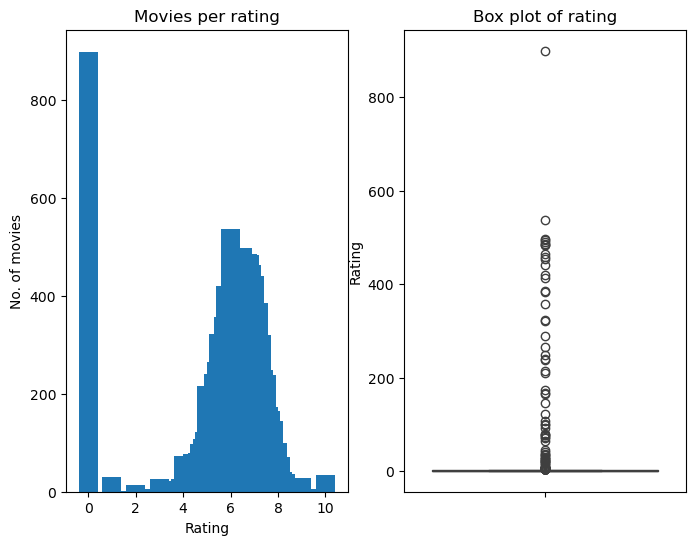

In [6]:
movies_per_year = movies_df['rating'].value_counts()

plt.figure(figsize=(8, 6))

plt.subplot(121)
plt.bar(movies_per_year.index, movies_per_year, color='C0')
plt.title('Movies per rating')
plt.xlabel('Rating')
plt.ylabel('No. of movies')

plt.subplot(122)
plt.title('Box plot of rating')
sns.boxplot(data=movies_per_year)
plt.ylabel('Rating')

plt.show()

rating
0.000     2.635934e+06
1.000     0.000000e+00
1.500     0.000000e+00
1.800     5.000000e+03
1.899     6.500000e+07
              ...     
9.300     0.000000e+00
9.400     0.000000e+00
9.500     0.000000e+00
9.800     0.000000e+00
10.000    1.258622e+05
Name: budget, Length: 2145, dtype: float64


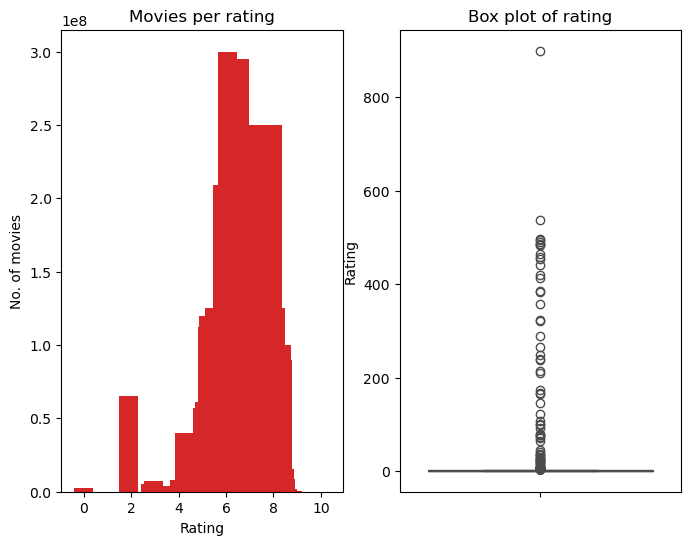

In [ ]:
plt.figure(figsize=(8, 6))

plt.subplot(121)
plt.bar(grouped_by_rating.index, grouped_by_rating, color='C3')
plt.title('Movies per rating')
plt.xlabel('Rating')
plt.ylabel('No. of movies')

plt.subplot(122)
plt.title('Box plot of rating')
sns.boxplot(data=movies_per_year, color='C3')
plt.ylabel('Rating')

plt.show()